Sistema de Detección de Fraude Híbrido (Tabular + NLP)
------------------------------------------------------
Este script entrena y despliega un modelo de ensamblado (Stacking) que combina:
1. XGBoost: Para análisis de datos estructurados (tabulares).
2. DistilBERT + Keras NN: Para análisis de texto (descripciones de siniestros).
3. Meta-Learner (Keras): Para combinar las predicciones de ambos modelos.
Incluye una interfaz gráfica generada con ipywidgets para pruebas en tiempo real.


In [1]:
import numpy as np
import tensorflow as tf
import random
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from google.colab import drive
import torch
from transformers import AutoTokenizer, AutoModel

In [2]:
# ==============================================================================
# CONFIGURACIÓN INICIAL Y REPRODUCIBILIDAD
# ==============================================================================
def set_random_seed(seed_value):
    """
    Fija las semillas generadoras de números aleatorios para garantizar
    la reproducibilidad de los resultados en múltiples ejecuciones.

    Args:
        seed_value (int): Valor de la semilla a utilizar.
    """
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    print(f"[*] Semillas aleatorias fijadas en {seed_value}.")

set_random_seed(42)
plt.style.use('ggplot')


[*] Semillas aleatorias fijadas en 42.


In [3]:
# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS TABULARES
# ==============================================================================
print("\n[*] 1. Cargando datos...")
drive.mount('/content/drive/')
file_path = '/content/drive/My Drive/Data/dataset_reclamos_ia_ruidoso_extremo.xlsx'

df = pd.read_excel(file_path)


[*] 1. Cargando datos...
Mounted at /content/drive/


In [4]:
# ==============================================================================
# 1.1 PREPARACIÓN DE DATOS TABULARES
# ==============================================================================

print("[*] Feature Engineering Tabular...")
# Conversión de columnas de fecha a objetos datetime
date_cols = ['Incident_Date', 'Date_Reported', 'Policy_Start_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Creación de nuevas variables predictoras basadas en tiempo
# Report_Delay: cantidad de días transcurridos entre la fecha de reporte del siniestro y la fecha del siniestro
df['Report_Delay'] = (df['Date_Reported'] - df['Incident_Date']).dt.days.fillna(0)
# Days_Since_Policy: cantidad de días transcurridos entre la fecha del siniestro y el inicio de vigencia de la póliza
df['Days_Since_Policy'] = (df['Incident_Date'] - df['Policy_Start_Date']).dt.days.fillna(0)
max_model_year = df['Model_Year'].max()
# Car_Age: Edad del vehículo respecto a la cartera de vehículos asegurados
df['Car_Age'] = max_model_year - df['Model_Year']

# Eliminación de columnas no útiles para el modelo
df = df.select_dtypes(exclude=['datetime64'])
df = df.drop(columns=['Claim_ID', 'Policy_Number', 'Last_Purchase_History_Date'], errors='ignore')

# Codificación de variables categóricas a valores numéricos
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Claim_Description':  # Excluimos el texto libre
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Separación de características (X) y variable objetivo (y)
X_tab_df = df.drop(columns=['Claim_Description', 'Prediccion_Fraude'])
X_tab_features = X_tab_df.columns.tolist()
X_tab = X_tab_df.values
y = df['Prediccion_Fraude'].values
text_data = df['Claim_Description'].astype(str).tolist()


[*] Feature Engineering Tabular...


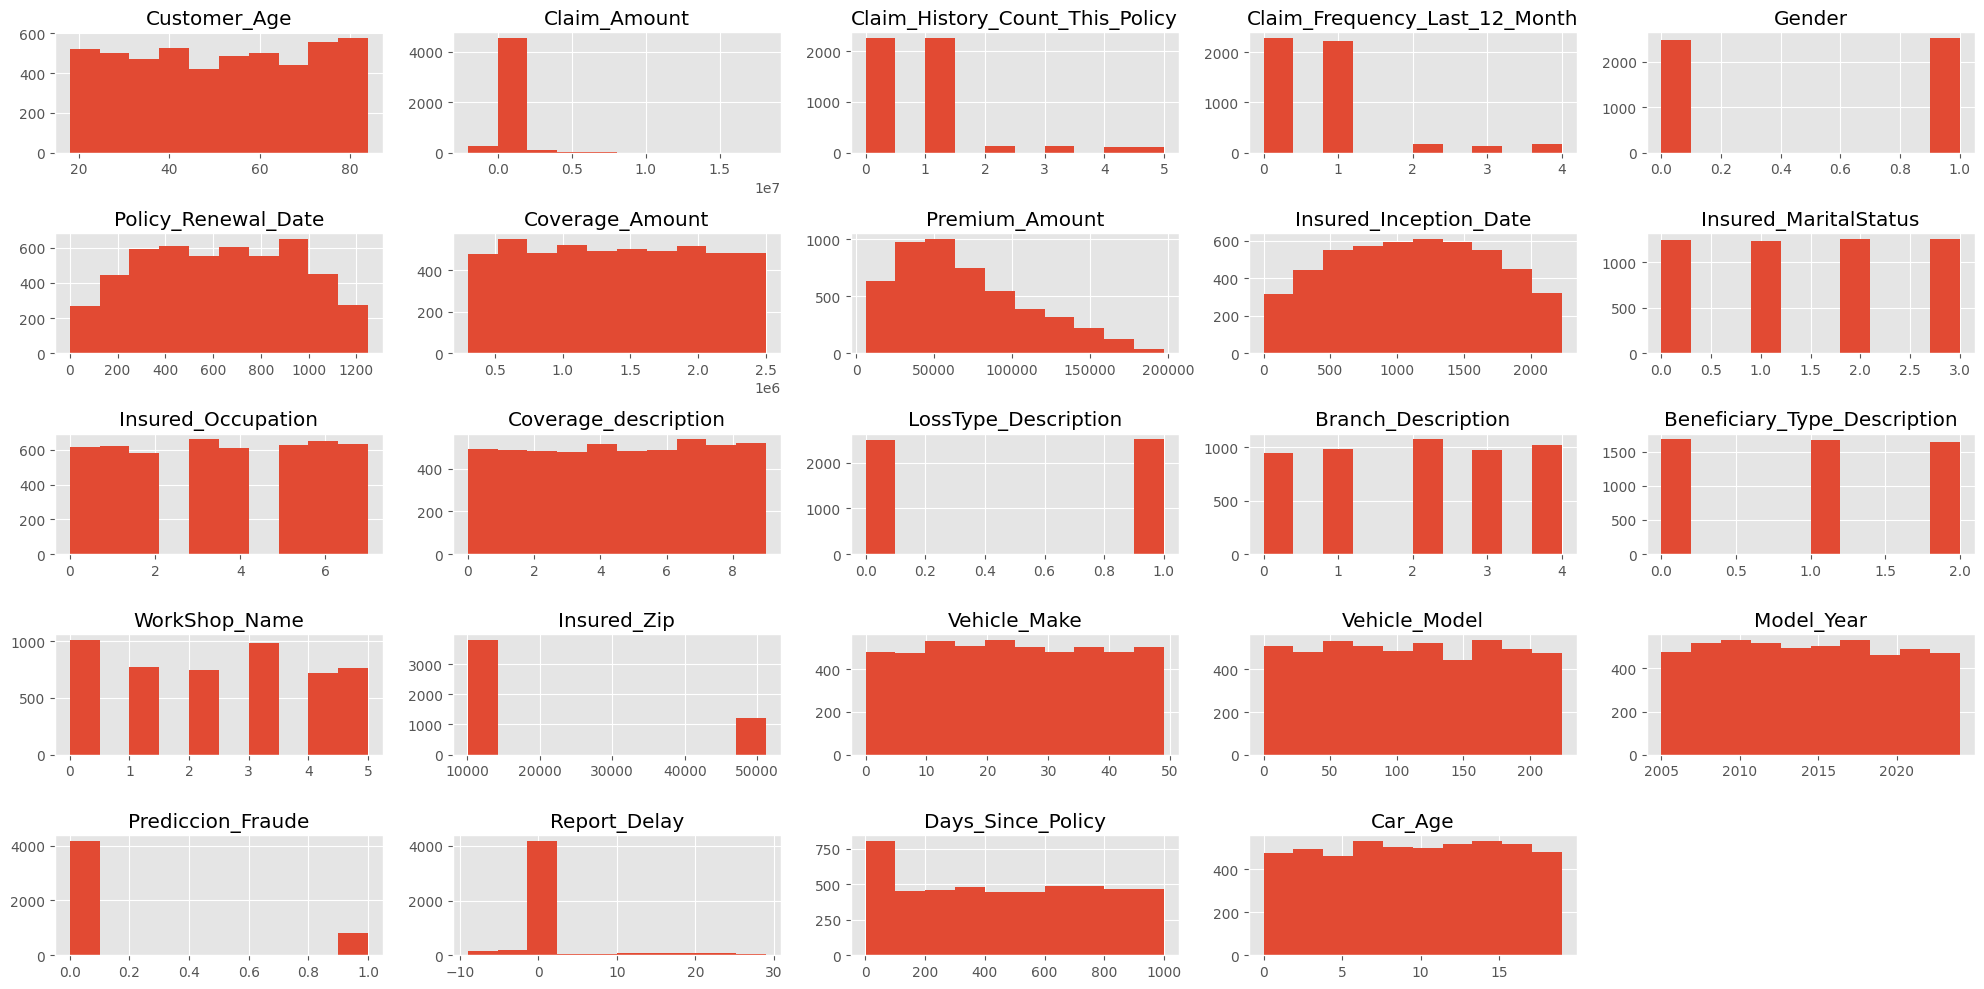

In [6]:
# ==============================================================================
# 1.2 EDA - Análisis exploratorio de los datos
# ==============================================================================
# Dibujar histogramas de todos los atributos
plt.rcParams['figure.figsize'] = [20, 10]
df.hist()
plt.subplots_adjust(wspace=0.5, hspace=0.5) # Add spacing between subplots
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [7]:
print(f'la cantidad de registros: {df.shape[0]:,}')
print(f'la cantidad de columnas:  {df.shape[1]}')

la cantidad de registros: 5,000
la cantidad de columnas:  25


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   int64  
 6   Policy_Renewal_Date              5000 non-null   int64  
 7   Coverage_Amount                  5000 non-null   float64
 8   Premium_Amount                   5000 non-null   float64
 9   Insured_Inception_Date           5000 non-null   int64  
 10  Insured_MaritalStatus            5000 non-null   int64  
 11  Insured_Occupation               5000 non-null   int64  
 12  Coverage_description

In [11]:
df.describe()

,Customer_Age,Claim_Amount,Claim_History_Count_This_Policy,Claim_Frequency_Last_12_Month,Gender,Policy_Renewal_Date,Coverage_Amount,Premium_Amount,Insured_Inception_Date,Insured_MaritalStatus,...,Beneficiary_Type_Description,WorkShop_Name,Insured_Zip,Vehicle_Make,Vehicle_Model,Model_Year,Prediccion_Fraude,Report_Delay,Days_Since_Policy,Car_Age
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.00000,5.000000e+03,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,51.445800,5.123133e+05,0.790000,0.744800,0.503800,627.95900,1.393368e+06,69661.274700,1120.415000,1.505000,...,0.993200,2.387400,20494.476000,24.520400,111.153000,2014.396400,0.163000,2.003600,468.814200,9.603600
std,19.617993,1.105958e+06,1.056467,0.932227,0.500036,319.32403,6.326668e+05,41173.578766,579.701919,1.119744,...,0.816387,1.723228,17232.288568,14.289017,64.312353,5.696328,0.369403,5.511593,306.620784,5.696328
min,18.000000,-2.062464e+06,0.000000,0.000000,0.000000,0.00000,3.002414e+05,6097.460000,0.000000,0.000000,...,0.000000,0.000000,10101.000000,0.000000,0.000000,2005.000000,0.000000,-9.000000,1.000000,0.000000
25%,34.000000,1.246255e+05,0.000000,0.000000,0.000000,360.00000,8.461657e+05,37495.602500,647.750000,1.000000,...,0.000000,1.000000,10509.000000,12.000000,57.000000,2010.000000,0.000000,0.000000,199.000000,5.000000
50%,51.000000,2.679759e+05,1.000000,1.000000,1.000000,629.00000,1.390053e+06,61105.690000,1123.000000,2.000000,...,1.000000,2.000000,10580.000000,24.000000,110.000000,2014.000000,0.000000,1.000000,465.000000,10.000000
75%,69.000000,5.328603e+05,1.000000,1.000000,1.000000,900.25000,1.933804e+06,95155.692500,1590.000000,3.000000,...,2.000000,4.000000,11503.000000,37.000000,166.000000,2019.000000,0.000000,2.000000,737.000000,14.000000
max,84.000000,1.813367e+07,5.000000,4.000000,1.000000,1249.00000,2.499897e+06,197530.810000,2232.000000,3.000000,...,2.000000,5.000000,51200.000000,49.000000,224.000000,2024.000000,1.000000,29.000000,999.000000,19.000000


In [12]:
df.head(20)

,Customer_Age,Claim_Amount,Claim_History_Count_This_Policy,Claim_Frequency_Last_12_Month,Claim_Description,Gender,Policy_Renewal_Date,Coverage_Amount,Premium_Amount,Insured_Inception_Date,...,Beneficiary_Type_Description,WorkShop_Name,Insured_Zip,Vehicle_Make,Vehicle_Model,Model_Year,Prediccion_Fraude,Report_Delay,Days_Since_Policy,Car_Age
0,74,116281.22,0,1,"El 15 de octubre, mientras manejaba por la Av....",1,1038,1756012.19,50844.40,1902,...,1,0,51100,40,163,2021,0,1,112,3
1,44,68880.28,0,0,"El 24 de octubre, tuve un accidente mientras c...",0,625,475779.24,26602.04,733,...,0,0,10508,25,196,2024,0,1,654,0
2,23,351069.98,1,1,"El pasado 15 de octubre, tuve un accidente con...",0,490,995928.65,63822.09,1284,...,0,0,11503,30,161,2024,0,0,469,0
3,48,678643.73,1,0,"El 15 de octubre, mientras manejaba mi vehícul...",0,402,2106085.57,85587.93,1182,...,2,4,11501,33,44,2021,0,1,601,3
4,55,94343.33,0,0,El pasado 12 de octubre tuve un accidente con ...,1,766,345467.81,25060.79,592,...,1,0,11503,47,164,2022,0,2,192,2
5,68,604224.73,0,1,"El 22 de octubre, mientras conducía por la Ave...",0,606,1819547.56,52479.73,1843,...,1,4,10509,28,60,2010,0,2,524,14
6,34,129915.05,1,0,"El pasado martes, tuve un accidente con mi veh...",1,304,643758.13,47354.17,1419,...,1,5,11503,4,180,2007,0,2,834,17
7,59,479399.82,4,2,El vehículo se vio involucrado en un incidente...,0,1184,520662.96,22340.30,1719,...,1,0,10509,32,25,2015,1,20,5,9
8,20,55804.57,1,0,"El 15 de octubre, mientras conducía por la aut...",1,836,578501.02,45747.23,730,...,1,4,10520,34,142,2018,0,2,278,6
9,76,203073.90,1,0,"El 10 de octubre, tuve un accidente donde mi v...",1,237,588698.70,45949.72,226,...,1,5,10101,27,54,2015,0,1,791,9


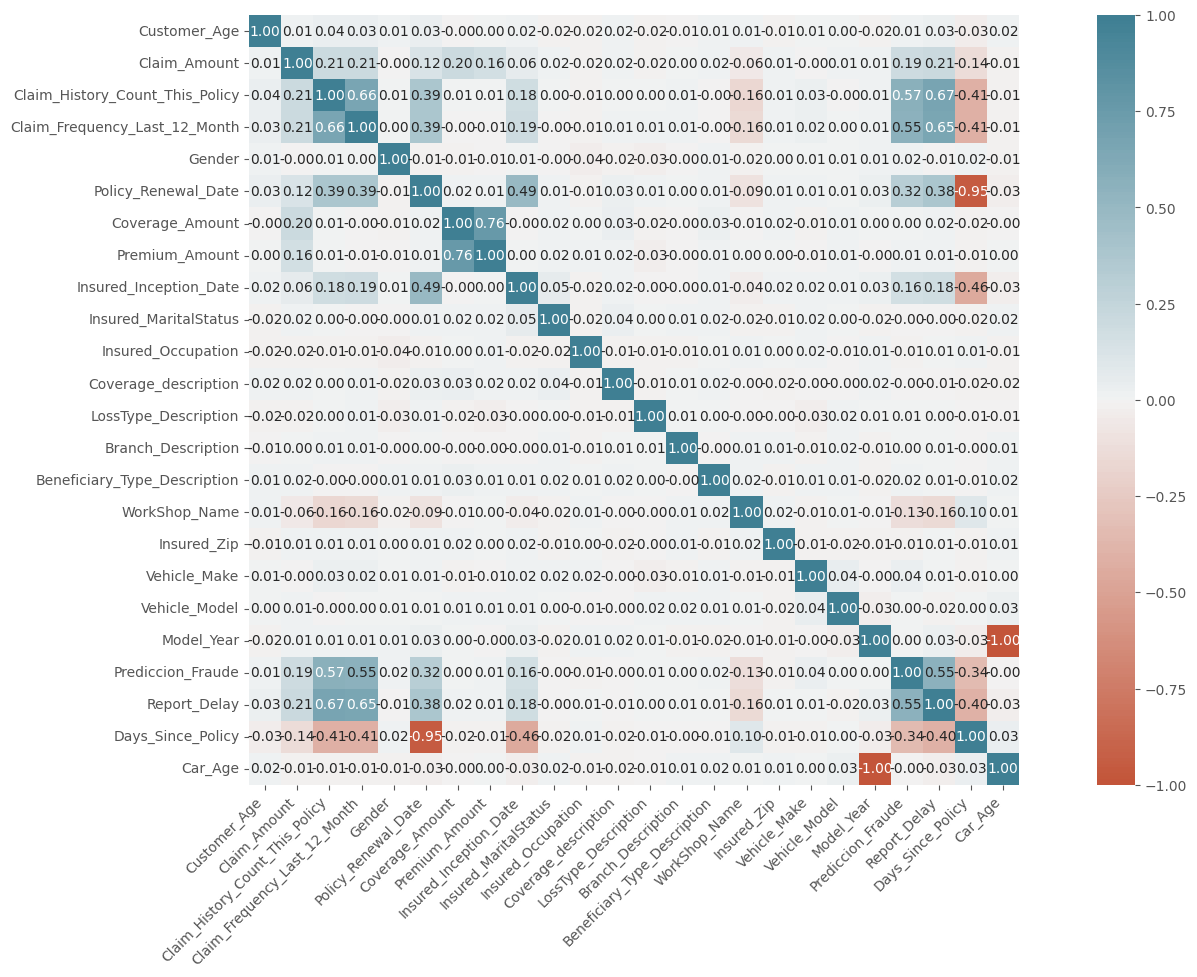

In [13]:
corr= df.corr(numeric_only=True)
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True, # mostrar los valores dentro de cada celda
    fmt=".2f" # formato para los valores numericos de la correlacion (2 decimales)
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

In [17]:
# Revisión de datos faltantes
col_total_nulos = df.isnull().sum()
serie_col_nombres = col_total_nulos[col_total_nulos > 0]
display(serie_col_nombres)

# contando los nulos por columna
df.isna().sum()

,0


,0
Customer_Age,0
Claim_Amount,0
Claim_History_Count_This_Policy,0
Claim_Frequency_Last_12_Month,0
Claim_Description,0
Gender,0
Policy_Renewal_Date,0
Coverage_Amount,0
Premium_Amount,0
Insured_Inception_Date,0


In [18]:
# Revisar valores en cero
(df==0).sum(axis=0)

,0
Customer_Age,0
Claim_Amount,0
Claim_History_Count_This_Policy,2255
Claim_Frequency_Last_12_Month,2280
Claim_Description,0
Gender,2481
Policy_Renewal_Date,1
Coverage_Amount,0
Premium_Amount,0
Insured_Inception_Date,1


All numerical columns: ['Customer_Age', 'Claim_Amount', 'Claim_History_Count_This_Policy', 'Claim_Frequency_Last_12_Month', 'Gender', 'Policy_Renewal_Date', 'Coverage_Amount', 'Premium_Amount', 'Insured_Inception_Date', 'Insured_MaritalStatus', 'Insured_Occupation', 'Coverage_description', 'LossType_Description', 'Branch_Description', 'Beneficiary_Type_Description', 'WorkShop_Name', 'Insured_Zip', 'Vehicle_Make', 'Vehicle_Model', 'Model_Year', 'Prediccion_Fraude', 'Report_Delay', 'Days_Since_Policy', 'Car_Age']
big_values_columns column: ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount', 'Insured_Zip', 'Model_Year', 'Customer_Age']
Other numerical columns (excluding Claim_Amount): ['Claim_History_Count_This_Policy', 'Claim_Frequency_Last_12_Month', 'Gender', 'Policy_Renewal_Date', 'Insured_Inception_Date', 'Insured_MaritalStatus', 'Insured_Occupation', 'Coverage_description', 'LossType_Description', 'Branch_Description', 'Beneficiary_Type_Description', 'WorkShop_Name', 'Vehicle_Make

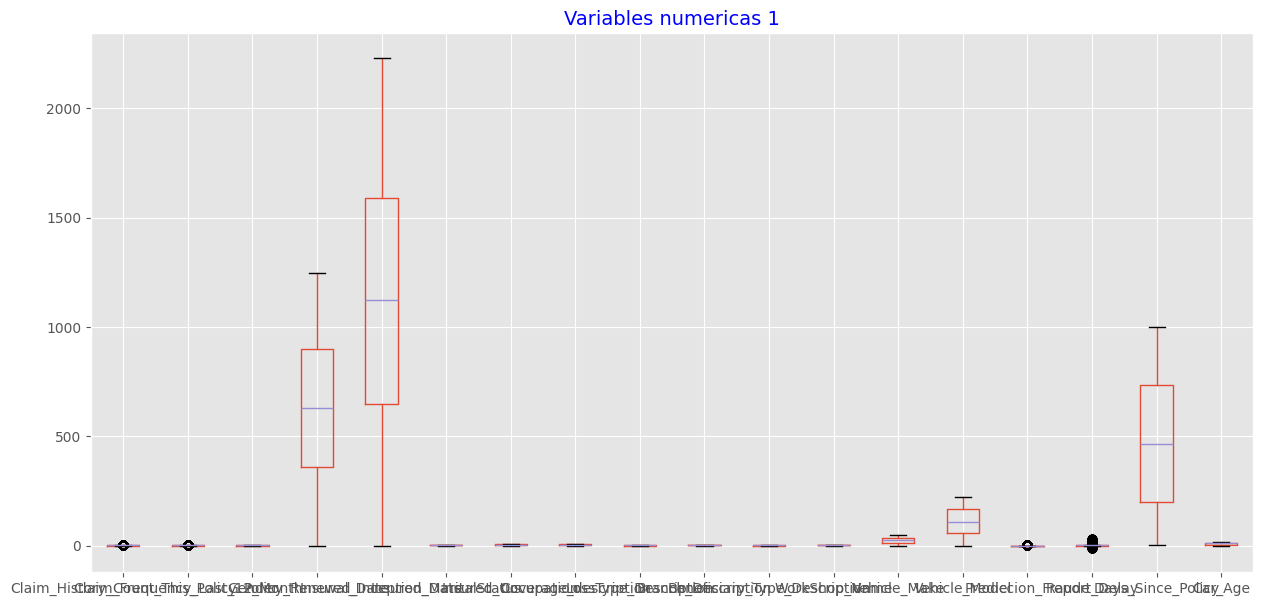

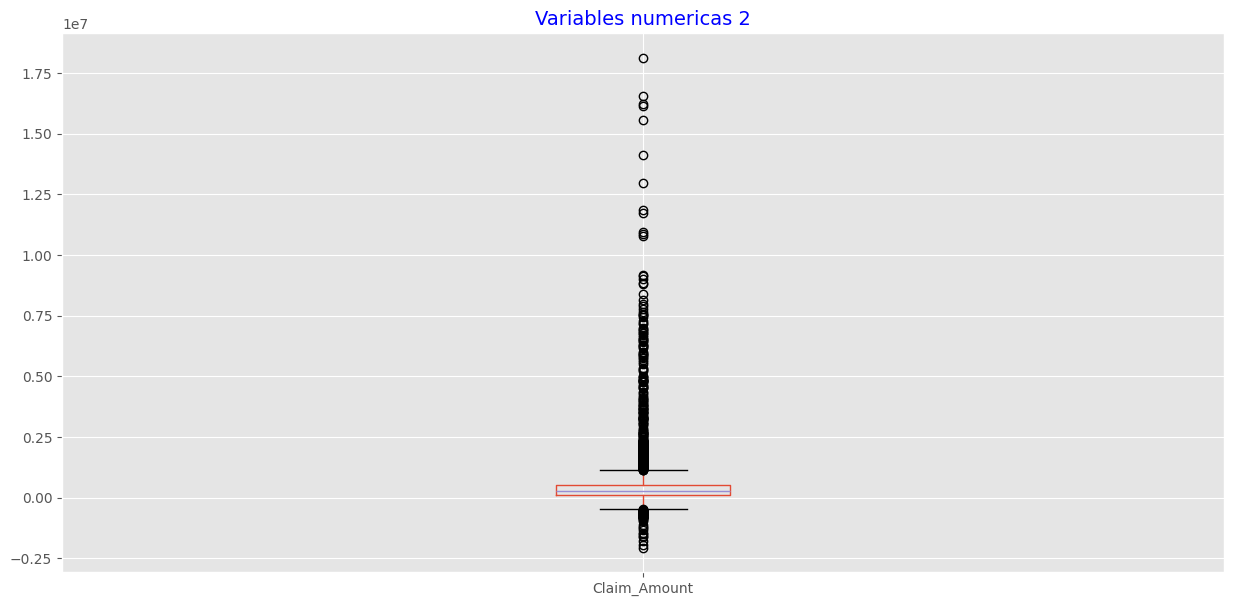

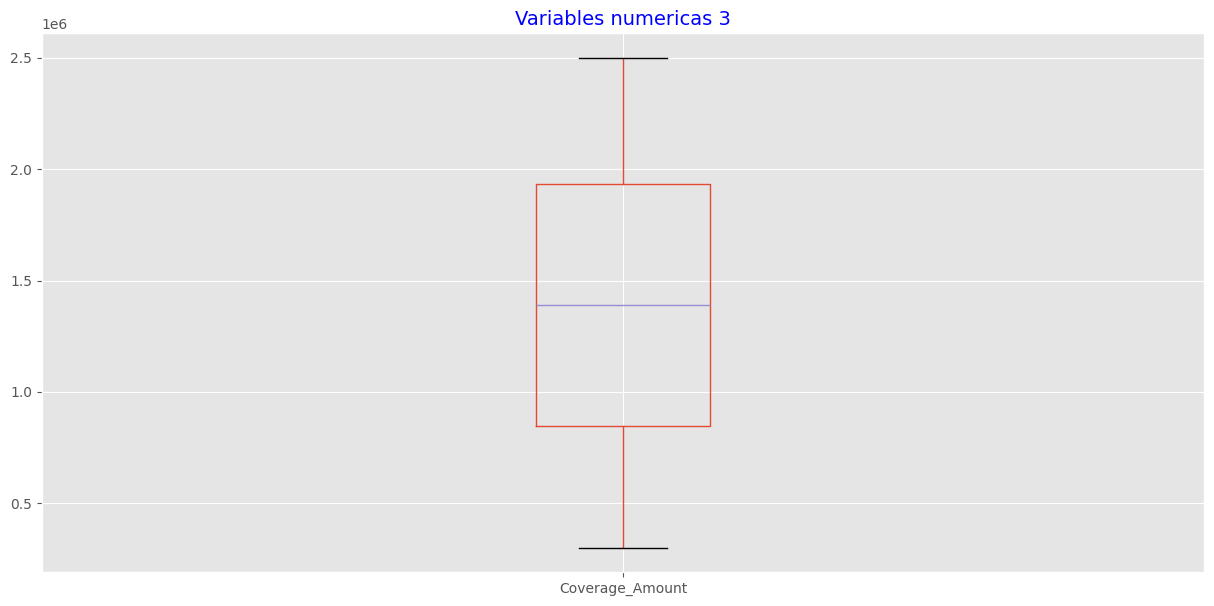

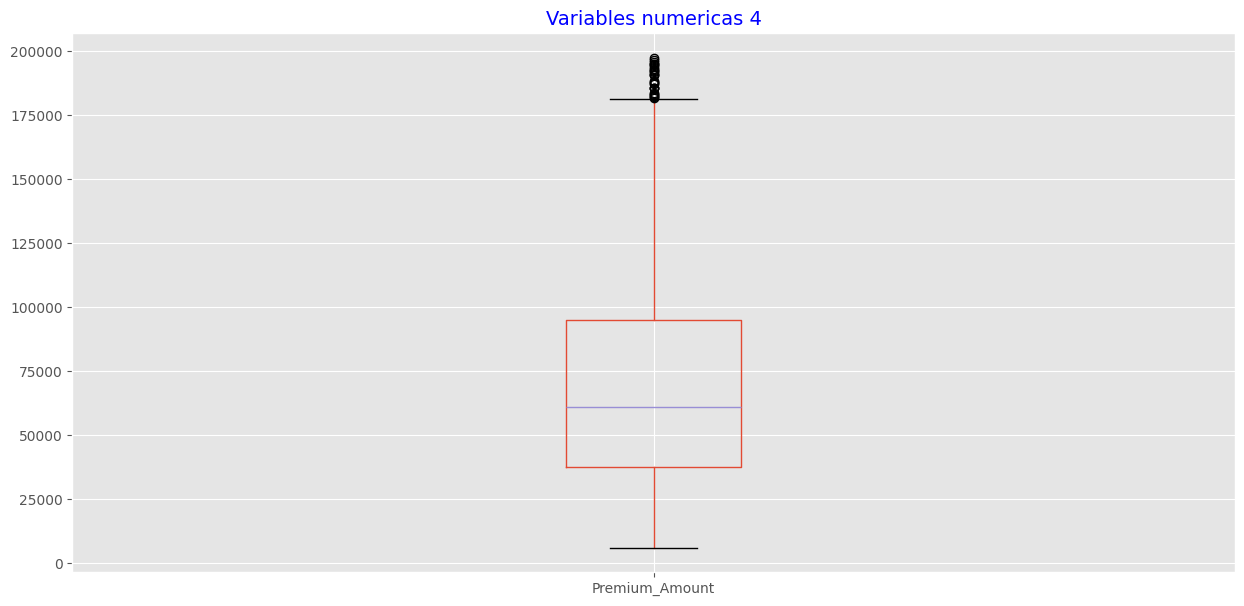

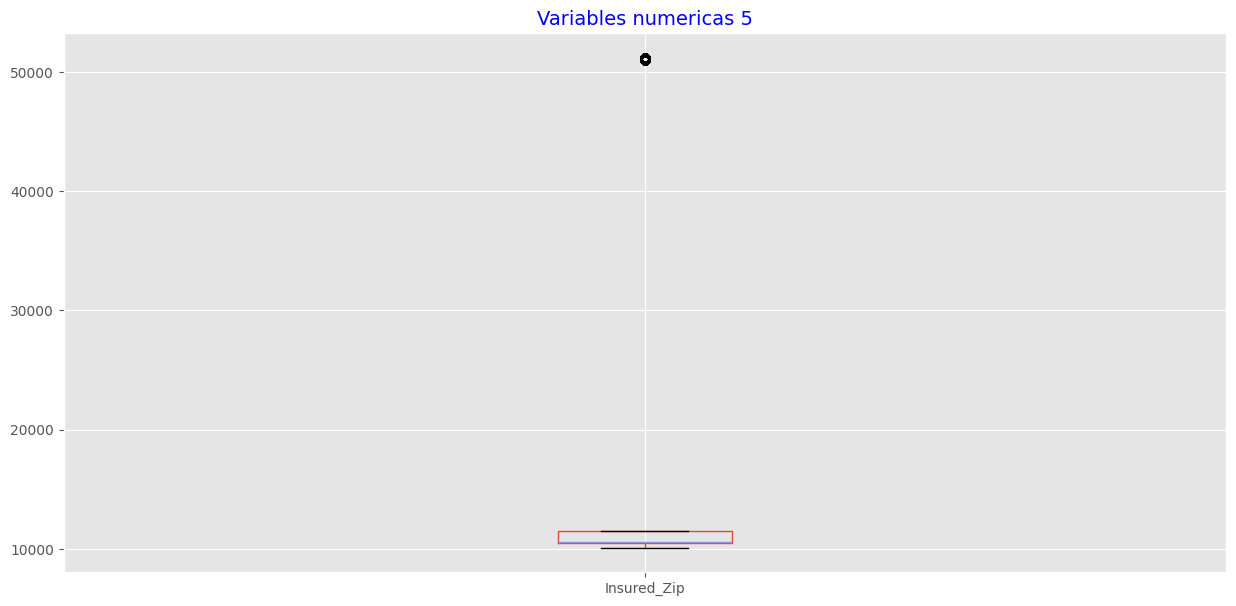

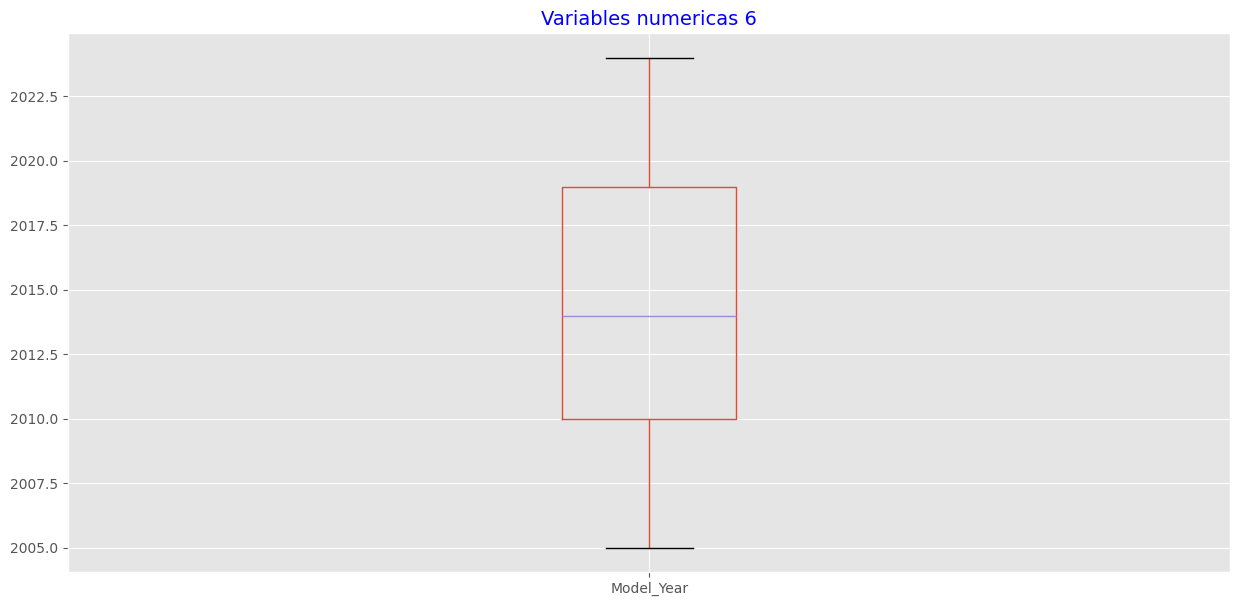

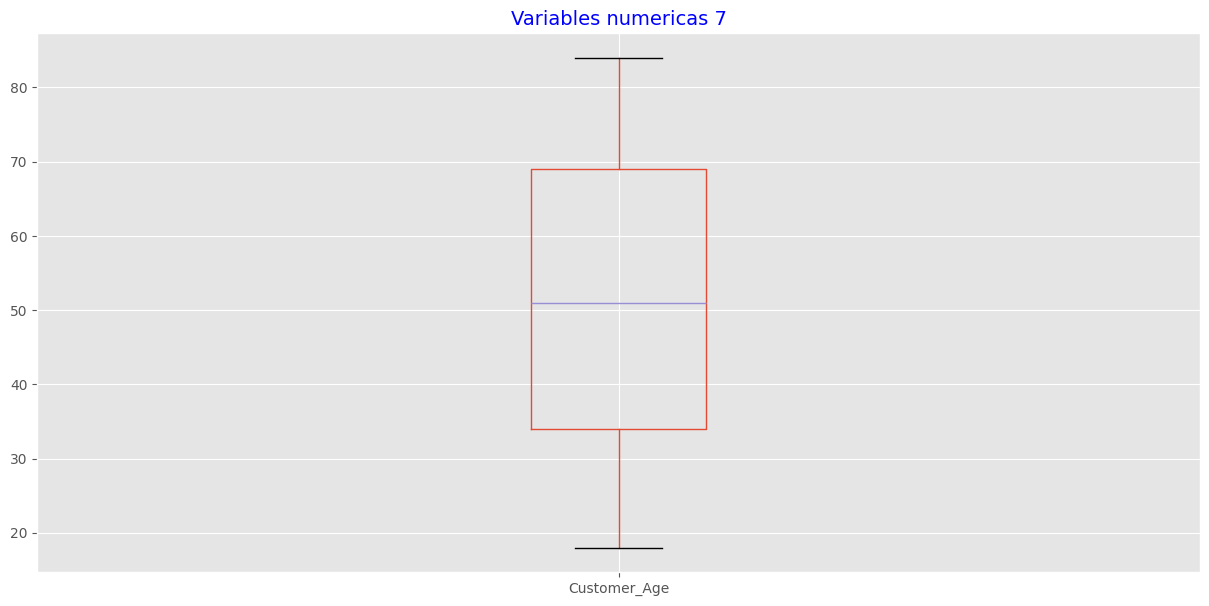

In [21]:
# Se grafican los diagramas de cajas y bigotes de cada una de las variables numéricas
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
big_values_columns = ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount', 'Insured_Zip', 'Model_Year', 'Customer_Age']
small_numerical_cols = [col for col in numerical_cols if col not in big_values_columns]


print(f"All numerical columns: {numerical_cols}")
print(f"big_values_columns column: {big_values_columns}")
print(f"Other numerical columns (excluding Claim_Amount): {small_numerical_cols}")

boxplot = df[small_numerical_cols].boxplot(figsize=(15,7))
plt.title("Variables numericas 1", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Claim_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 2", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Coverage_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 3", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Premium_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 4", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Insured_Zip']].boxplot(figsize=(15,7))
plt.title("Variables numericas 5", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Model_Year']].boxplot(figsize=(15,7))
plt.title("Variables numericas 6", fontsize=14, color='blue')
plt.show()
print(' ')

boxplot = df[['Customer_Age']].boxplot(figsize=(15,7))
plt.title("Variables numericas 7", fontsize=14, color='blue')
plt.show()
print(' ')



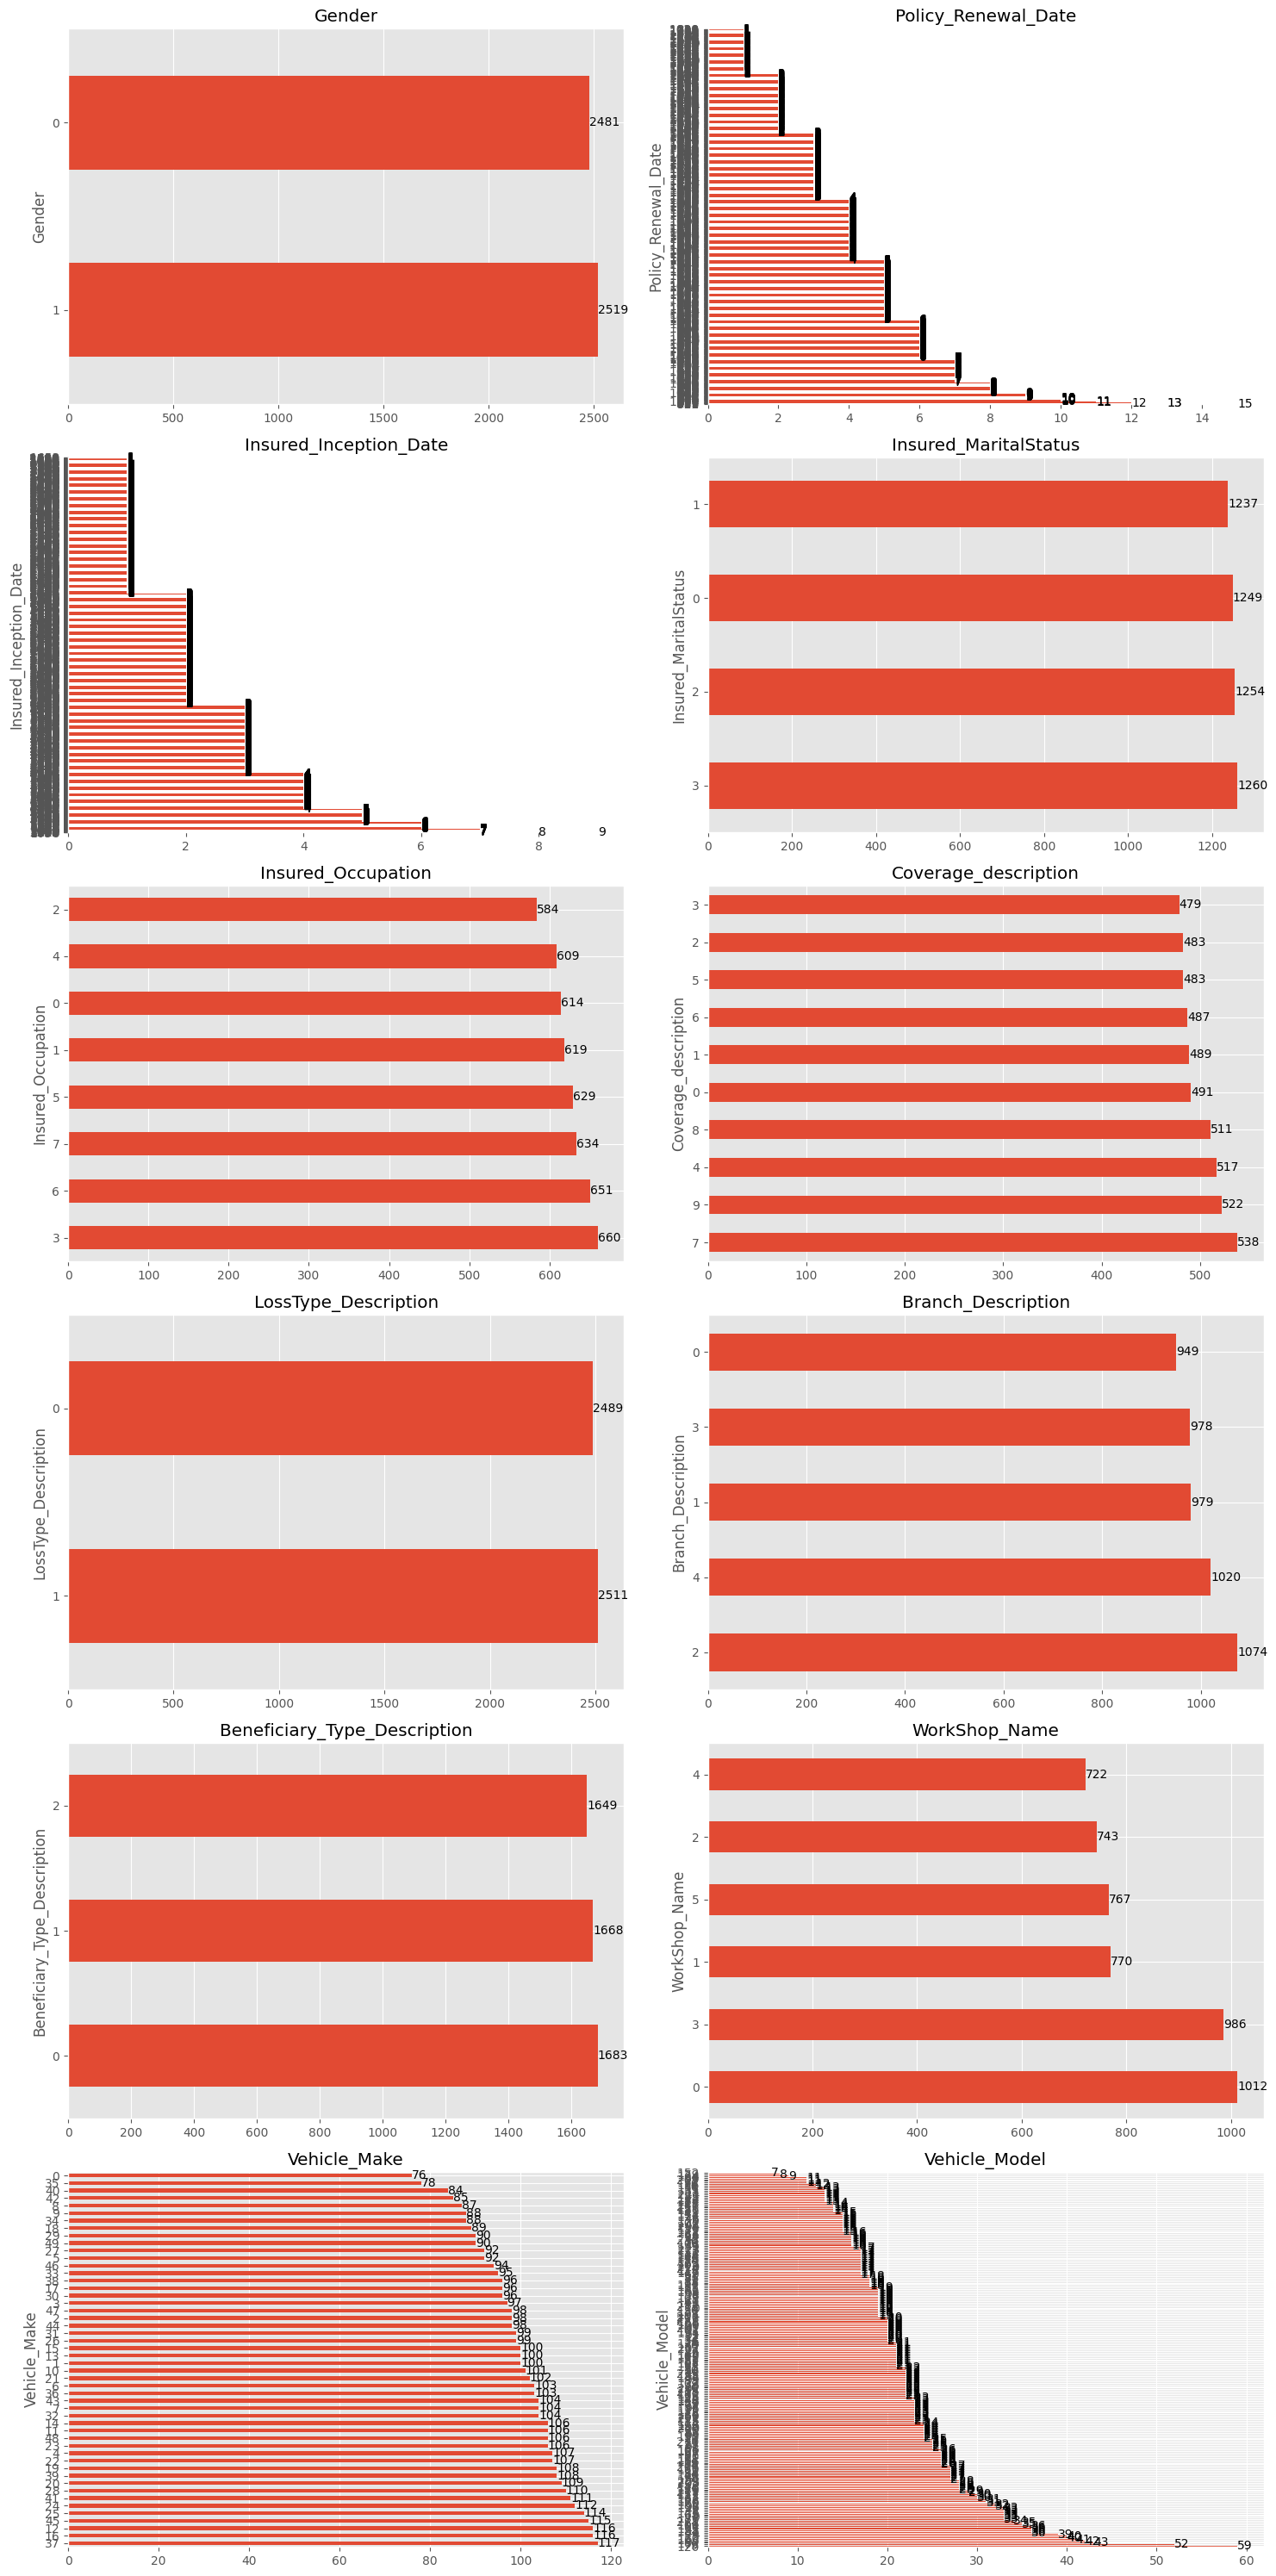

In [22]:
# Se grafican las variables categoricas

lst_var_cat = list(label_encoders.keys()) # Use the keys from label_encoders for categorical columns

# Calculate the number of rows needed for subplots
num_categorical_cols = len(lst_var_cat)
nrows = (num_categorical_cols + 1) // 2  # Divide by 2 and round up for rows
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(15, 5 * nrows)) # Adjust figsize dynamically

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

# Flatten axes for easier iteration if it's a 2D array, otherwise keep as 1D
axes = axes.flatten() if num_categorical_cols > 1 else [axes]

for i, col in enumerate(lst_var_cat):
    if i < len(axes): # Ensure we don't go out of bounds if there are fewer axes than columns
        df[col].value_counts().plot.barh(ax=axes[i])
        axes[i].set_title(col)
        axes[i].bar_label(axes[i].containers[0])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Número de registros por clase


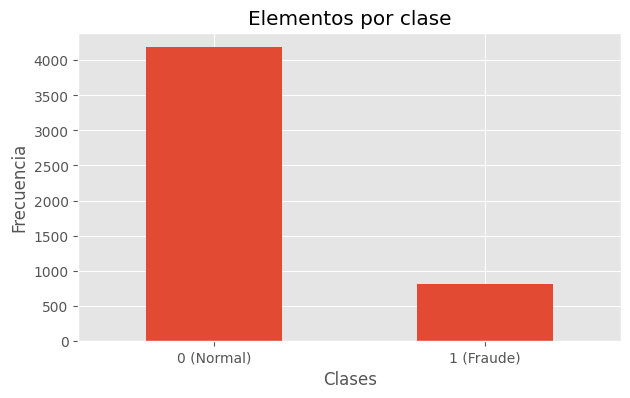

In [24]:
# Distribución por Clase

class_labels = ['0 (Normal)', '1 (Fraude)']

print("Número de registros por clase")
# Obtener el conteo de cada clase y ordenarlo por índice
class_counts = df['Prediccion_Fraude'].value_counts().sort_index()
ax = class_counts.plot(kind='bar',
                        figsize=(7,4),
                        title="Elementos por clase")

ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")
ax.set_xticklabels(class_labels)
plt.xticks(rotation=0)
plt.show()

# El dataset está desbalanceado por la natural del dato, lo normal es que no sea fraude

In [23]:
# ==============================================================================
# 2. PROCESAMIENTO NLP CON PYTORCH Y DISTILBERT (FEATURE EXTRACTION)
# ==============================================================================
print("\n[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...")

# Carga del tokenizador y modelo pre-entrenado
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model = AutoModel.from_pretrained("distilbert-base-multilingual-cased")

# Modo evaluación: apaga Dropout/BatchNorm ya que no re-entrenaremos DistilBERT
distilbert_model.eval()

# Asignación a GPU para acelerar la inferencia si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
distilbert_model.to(device)
print(f"[*] Usando dispositivo: {device}")

def extract_embeddings(text_list, batch_size=32):
    """
    Convierte una lista de textos en embeddings densos usando DistilBERT.

    Args:
        text_list (list): Lista de cadenas de texto (descripciones).
        batch_size (int): Tamaño del lote para procesar en memoria.

    Returns:
        np.ndarray: Matriz de dimensiones (N_textos, 768) con los embeddings.
    """
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        # Tokenización con truncamiento y padding dinámico
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=120, return_tensors="pt").to(device)

        # torch.no_grad() reduce el consumo de memoria VRAM al no calcular gradientes
        with torch.no_grad():
            outputs = distilbert_model(**inputs)

        # Extracción del token [CLS] (índice 0) que actúa como resumen semántico de la oración
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

print("[*] Convirtiendo todos los textos a Embeddings de DistilBERT (Esto tomará unos segundos)...")
X_text_embeddings = extract_embeddings(text_data)
print(f"[*] Embeddings generados con forma: {X_text_embeddings.shape} (Textos, Dimensiones)")



[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Usando dispositivo: cuda
[*] Convirtiendo todos los textos a Embeddings de DistilBERT (Esto tomará unos segundos)...
[*] Embeddings generados con forma: (5000, 768) (Textos, Dimensiones)


In [25]:
# ==============================================================================
# 3. DIVISION DE DATOS: TRAIN, VALIDATION, META Y TEST
# ==============================================================================
print("\n[*] 3. Dividiendo datos de forma estratificada...")

# División en 4 conjuntos manteniendo la proporción de clases (stratify)
# Esta división es crucial para los modelos de Stacking:
# - idx_train/y_train: Para entrenar los modelos base (XGBoost y Red Neuronal NLP).
# - idx_val/y_val: Para validar y ajustar hiperparámetros de los modelos base (ej. early stopping).
# - idx_meta/y_meta: Para generar las predicciones 'out-of-fold' de los modelos base,
#                    que luego se usarán como entradas para entrenar el Meta-Learner.
#                    Esto evita el 'data leakage' desde los modelos base al Meta-Learner.
# - idx_test/y_test: Para la evaluación final y no sesgada del rendimiento del modelo híbrido completo.
indices = np.arange(len(y))
idx_temp, idx_test, y_temp, y_test = train_test_split(indices, y, test_size=0.20, random_state=42, stratify=y)
idx_base, idx_meta, y_base, y_meta = train_test_split(idx_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
idx_train, idx_val, y_train, y_val = train_test_split(idx_base, y_base, test_size=0.20, random_state=42, stratify=y_base)

# Asignación de divisiones a los datos tabulares
X_tab_train, X_tab_val, X_tab_meta, X_tab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_meta], X_tab[idx_test]

# Asignación de divisiones a los datos de texto (Embeddings)
X_text_train = X_text_embeddings[idx_train]
X_text_val   = X_text_embeddings[idx_val]
X_text_meta  = X_text_embeddings[idx_meta]
X_text_test  = X_text_embeddings[idx_test]



[*] 3. Dividiendo datos de forma estratificada...


In [26]:
print(f"Cantidad de elementos para entrenamiento: {len(idx_train)}")
print(f"Cantidad de elementos para validacion: {len(idx_val)}")
print(f"Cantidad de elementos para meta: {len(idx_meta)}")
print(f"Cantidad de elementos para test: {len(idx_test)}")

Cantidad de elementos para entrenamiento: 2400
Cantidad de elementos para validacion: 600
Cantidad de elementos para meta: 1000
Cantidad de elementos para test: 1000


In [27]:
# ==============================================================================
# FUNCIONES DE EVALUACIÓN
# ==============================================================================
def evaluate_and_plot_metrics(y_true, y_pred_prob, model_name, threshold=0.5, history=None):
    """
    Calcula métricas de clasificación y genera gráficos (Matriz de Confusión y Curva ROC).
    Opcionalmente, grafica la evolución del accuracy y loss durante el entrenamiento
    si se proporciona un objeto history de Keras.

    Args:
        y_true (array): Etiquetas reales.
        y_pred_prob (array): Probabilidades predichas por el modelo.
        model_name (str): Nombre del modelo evaluado (para títulos de gráficos).
        threshold (float): Umbral para convertir probabilidad en clase binaria.
        history (tensorflow.keras.callbacks.History, optional): Objeto History de Keras
                                                            que contiene los registros de entrenamiento.
    """
    if history:
        # Gráficos de Accuracy y Loss
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Plot training & validation accuracy values
        ax1.plot(history.history['accuracy'])
        ax1.plot(history.history['val_accuracy'])
        ax1.set_title(f'Accuracy del Modelo {model_name}')
        ax1.set_ylabel('Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.legend(['Train', 'Validation'], loc='upper left')

        # Plot training & validation loss values
        ax2.plot(history.history['loss'])
        ax2.plot(history.history['val_loss'])
        ax2.set_title(f'Loss del Modelo {model_name}')
        ax2.set_ylabel('Loss')
        ax2.set_xlabel('Epoch')
        ax2.legend(['Train', 'Validation'], loc='upper left')
        plt.show()

    y_pred_bin = (y_pred_prob > threshold).astype(int)
    print(f"\n" + "="*60 + f"\n📈 EVALUACIÓN EN TEST SET: {model_name}\n" + "="*60)
    print(f"F1-Score: {f1_score(y_true, y_pred_bin):.4f} | AUC-ROC: {roc_auc_score(y_true, y_pred_prob):.4f}\n")
    print(classification_report(y_true, y_pred_bin, target_names=['Normal', 'Fraude']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    sns.heatmap(confusion_matrix(y_true, y_pred_bin), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Matriz Confusión - {model_name}')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_true, y_pred_prob):.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title(f'Curva ROC - {model_name}')
    axes[1].legend(loc="lower right")
    plt.show()



🧠 ENTRENANDO XGBoost (Tabular)...
[0]	validation_0-logloss:0.67323	validation_0-error:0.12500	validation_1-logloss:0.67304	validation_1-error:0.12500
[1]	validation_0-logloss:0.65496	validation_0-error:0.10750	validation_1-logloss:0.65514	validation_1-error:0.12333
[2]	validation_0-logloss:0.63808	validation_0-error:0.10708	validation_1-logloss:0.63824	validation_1-error:0.12167
[3]	validation_0-logloss:0.62268	validation_0-error:0.09708	validation_1-logloss:0.62244	validation_1-error:0.09167
[4]	validation_0-logloss:0.60832	validation_0-error:0.09250	validation_1-logloss:0.60766	validation_1-error:0.08667
[5]	validation_0-logloss:0.59492	validation_0-error:0.09292	validation_1-logloss:0.59470	validation_1-error:0.09000
[6]	validation_0-logloss:0.58252	validation_0-error:0.09500	validation_1-logloss:0.58243	validation_1-error:0.09000
[7]	validation_0-logloss:0.57092	validation_0-error:0.08958	validation_1-logloss:0.57087	validation_1-error:0.08167
[8]	validation_0-logloss:0.56005	vali

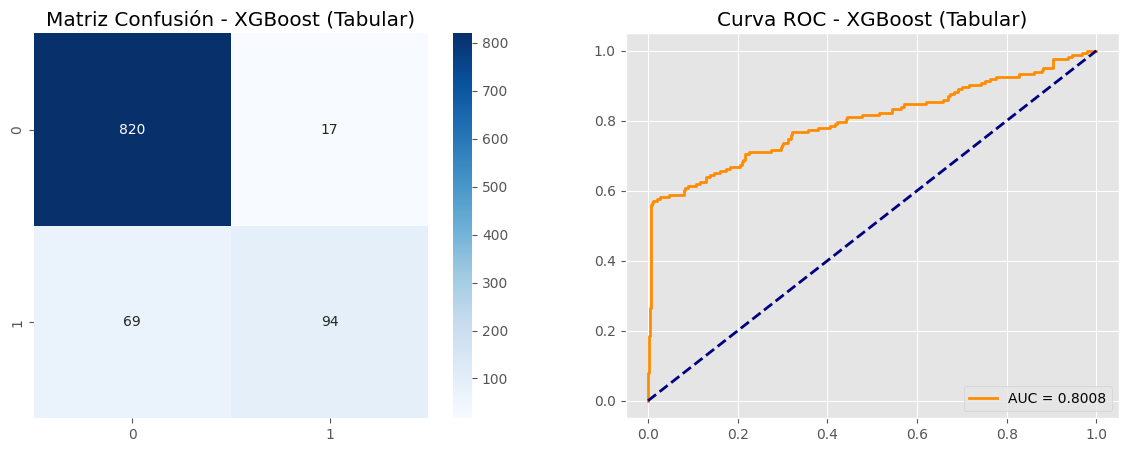

In [37]:
# ==============================================================================
# 4. MODELO 1: XGBOOST (DATOS TABULARES)
# ==============================================================================
print("\n🧠 ENTRENANDO XGBoost (Tabular)...")
# scale_pos_weight ayuda a XGBoost a penalizar más los errores en la clase minoritaria (fraude)
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=6,
    scale_pos_weight=float(np.sum(y_train==0)/np.sum(y_train==1)),
    eval_metric=["logloss", "error"]
)
model_tab = xgb_model.fit(X_tab_train, y_train, eval_set=[(X_tab_train, y_train), (X_tab_val, y_val)], verbose=True)
evaluate_and_plot_metrics(y_test, xgb_model.predict_proba(X_tab_test)[:, 1], "XGBoost (Tabular)")



🧠 ENTRENANDO RED NEURONAL (Sobre Embeddings de DistilBERT)...
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9079 - loss: 0.2773 - val_accuracy: 0.9700 - val_loss: 0.1033
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9679 - loss: 0.1070 - val_accuracy: 0.9817 - val_loss: 0.0553
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0642 - val_accuracy: 0.9850 - val_loss: 0.0341
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0412 - val_accuracy: 0.9950 - val_loss: 0.0127
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9892 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 0.0047


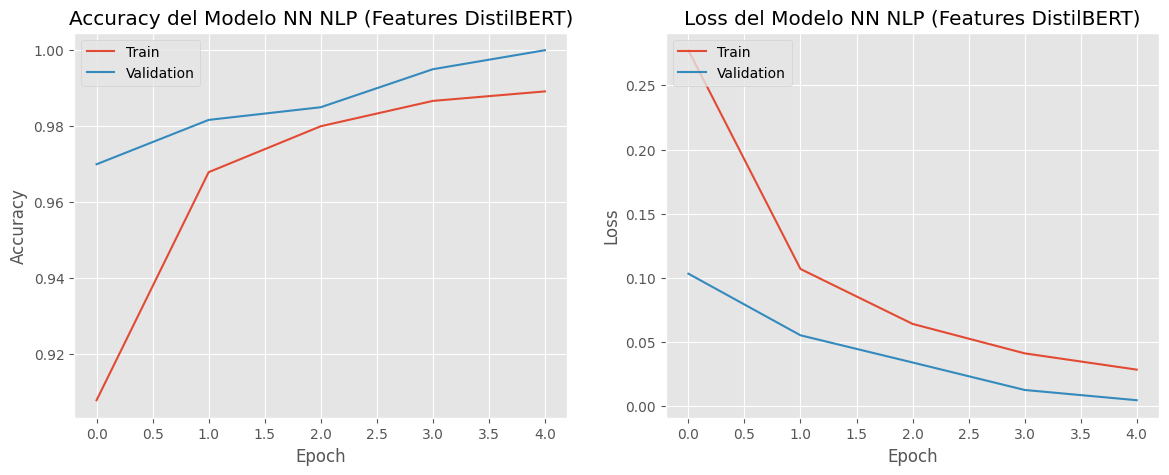


📈 EVALUACIÓN EN TEST SET: NN NLP (Features DistilBERT)
F1-Score: 0.9879 | AUC-ROC: 1.0000

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       837
      Fraude       0.98      1.00      0.99       163

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



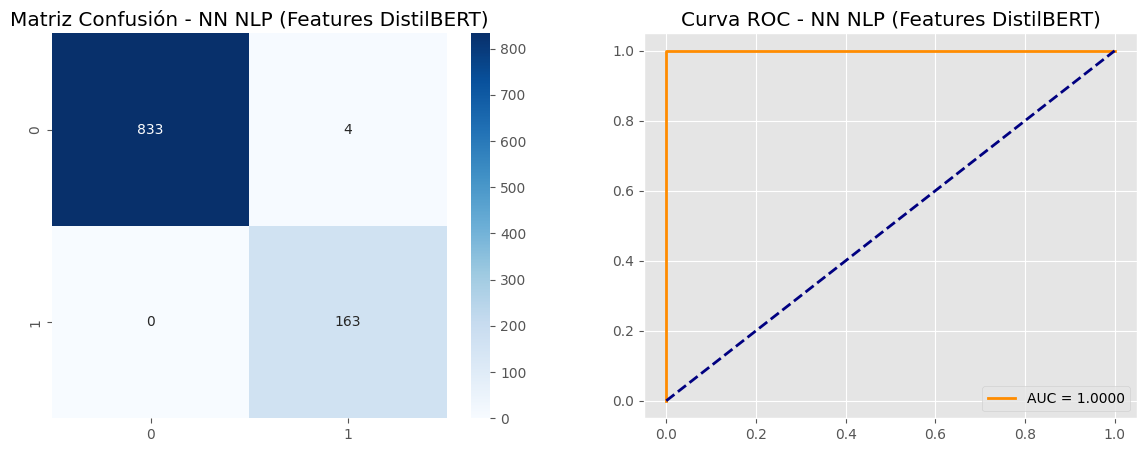

In [38]:
# ==============================================================================
# 5. MODELO 2: RED NEURONAL DE KERAS (Recibiendo Embeddings)
# ==============================================================================
print("\n🧠 ENTRENANDO RED NEURONAL (Sobre Embeddings de DistilBERT)...")

# Arquitectura densa para clasificar los vectores de 768 dimensiones
input_text = Input(shape=(768,), name="text_embedding_input")
x = Dense(128, activation='relu')(input_text)
x = Dropout(0.5)(x) # Previene el sobreajuste (overfitting)
x = Dense(32, activation='relu')(x)
x = Dropout(0.4)(x)
output_text = Dense(1, activation='sigmoid')(x)

nn_text_model = Model(inputs=input_text, outputs=output_text)
nn_text_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Detiene el entrenamiento si no hay mejora en validación para evitar overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# Cálculo de pesos para lidiar con el desbalance de clases
class_weights_dict = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

# Entrenamiento rápido (los embeddings pesados ya fueron pre-calculados)
history_nn = nn_text_model.fit(
    X_text_train,
    y_train,
    validation_data=(X_text_val, y_val),
    epochs=5, #25
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

evaluate_and_plot_metrics(y_test, nn_text_model.predict(X_text_test, verbose=0).flatten(), "NN NLP (Features DistilBERT)", history=history_nn)



🧠 ENTRENANDO MODELO HÍBRIDO (META-LEARNER)...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1287 - loss: 0.7954 - val_accuracy: 0.2550 - val_loss: 0.7625
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2288 - loss: 0.7485 - val_accuracy: 0.3750 - val_loss: 0.7239
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3762 - loss: 0.7108 - val_accuracy: 0.5350 - val_loss: 0.6925
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6025 - loss: 0.6794 - val_accuracy: 0.6850 - val_loss: 0.6664
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8000 - loss: 0.6530 - val_accuracy: 0.8450 - val_loss: 0.6445
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8988 - loss: 0.6306 - val_accuracy: 0.8800 - val_loss: 0.6255
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9200 - loss: 0.6109 - val_accuracy: 0.9100 - val_loss: 0.6082
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.92

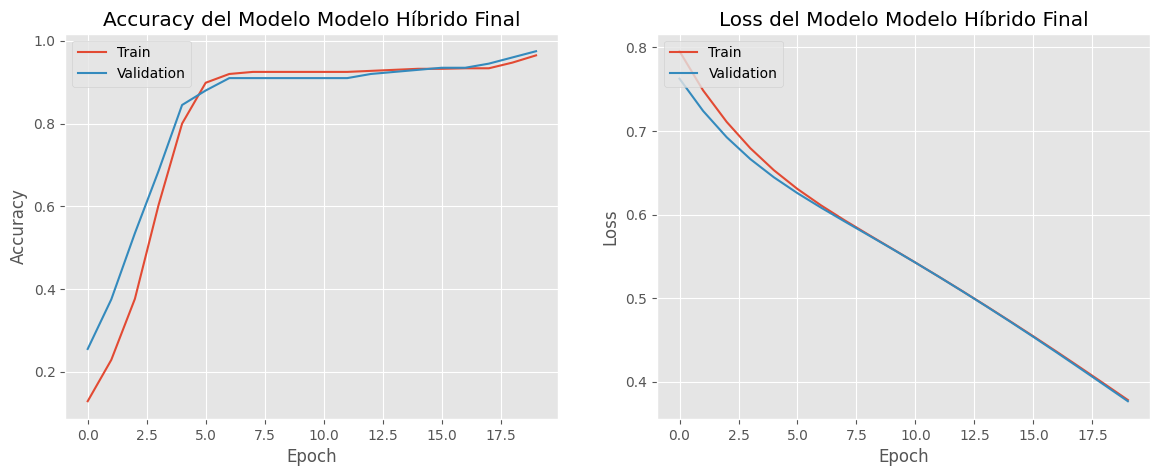


📈 EVALUACIÓN EN TEST SET: Modelo Híbrido Final
F1-Score: 0.9103 | AUC-ROC: 0.9995

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       837
      Fraude       0.99      0.84      0.91       163

    accuracy                           0.97      1000
   macro avg       0.98      0.92      0.95      1000
weighted avg       0.97      0.97      0.97      1000



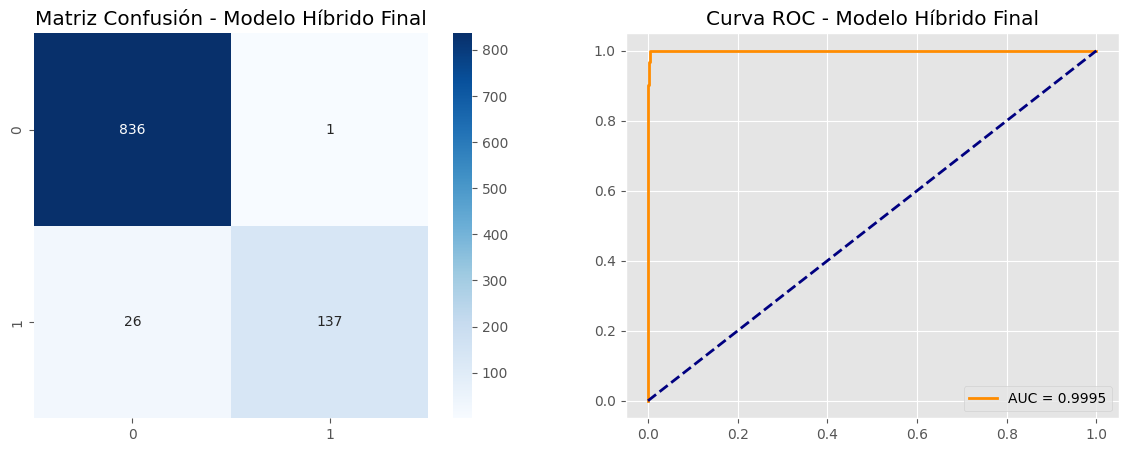

In [39]:
# ==============================================================================
# 6. MODELO 3: META-LEARNER (STACKING ENSEMBLE)
# ==============================================================================
print("\n🧠 ENTRENANDO MODELO HÍBRIDO (META-LEARNER)...")

# Generación de predicciones Out-of-Fold para entrenar el Meta-Learner
pred_meta_xgb = xgb_model.predict_proba(X_tab_meta)[:, 1]
pred_meta_nn = nn_text_model.predict(X_text_meta, verbose=0).flatten()

# Arquitectura del Meta-Learner (Red pequeña que toma las 2 probabilidades como entrada)
meta_input = Input(shape=(2,), name="meta_input")
x = Dense(8, activation='relu')(meta_input)
meta_output = Dense(1, activation='sigmoid')(x)

meta_nn = Model(inputs=meta_input, outputs=meta_output)
meta_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento del ensamble
history_meta_nn = meta_nn.fit(
    np.column_stack((pred_meta_xgb, pred_meta_nn)),
    y_meta,
    validation_split=0.2,
    epochs=20, #30 17
    verbose=1
)

def predecir_fraude_stacking(X_tab_nuevo, texto_nuevo_str):
    """
    Ejecuta el pipeline completo de predicción para datos nuevos.

    Args:
        X_tab_nuevo (array): Datos tabulares preprocesados.
        texto_nuevo_str (list): Lista con el texto crudo de la descripción.

    Returns:
        tuple: (Probabilidad global del ensemble, prob. XGBoost, prob. NN de texto)
    """
    p1 = xgb_model.predict_proba(X_tab_nuevo)[:, 1]

    # Extracción en vivo del embedding y predicción
    emb_nuevo = extract_embeddings(texto_nuevo_str)
    p2 = nn_text_model.predict(emb_nuevo, verbose=0).flatten()

    meta_in = np.column_stack((p1, p2))
    return meta_nn.predict(meta_in, verbose=0).flatten(), p1[0], p2[0]

pred_test_stacking, _, _ = predecir_fraude_stacking(X_tab_test, df['Claim_Description'].iloc[idx_test].tolist())
evaluate_and_plot_metrics(y_test, pred_test_stacking, "Modelo Híbrido Final", history=history_meta_nn)


In [41]:
# Comparar las metricas del modelo XGBoost versus el Hibrido Final

# Obtener predicciones para el modelo XGBoost
prob_xgb_test = xgb_model.predict_proba(X_tab_test)[:, 1]
y_pred_xgb_bin = (prob_xgb_test > 0.5).astype(int)
f1_xgb = f1_score(y_test, y_pred_xgb_bin)
auc_xgb = roc_auc_score(y_test, prob_xgb_test)

# Obtener predicciones para el modelo Híbrido Final (Stacking)
prob_stack_test, _, _ = predecir_fraude_stacking(X_tab_test, df['Claim_Description'].iloc[idx_test].tolist())
y_pred_stack_bin = (prob_stack_test > 0.5).astype(int)
f1_stack = f1_score(y_test, y_pred_stack_bin)
auc_stack = roc_auc_score(y_test, prob_stack_test)

print("\n--- Comparación de Métricas de Modelos ---")
print(f"XGBoost Model:")
print(f"  F1-Score: {f1_xgb:.4f}")
print(f"  AUC-ROC: {auc_xgb:.4f}")
print("\nHybrid Final Model (Stacking):")
print(f"  F1-Score: {f1_stack:.4f}")
print(f"  AUC-ROC: {auc_stack:.4f}")

print("\n--- Conclusión ---")
if f1_stack > f1_xgb:
    print("El Modelo Híbrido Final tiene un mejor F1-Score.")
elif f1_xgb > f1_stack:
    print("El Modelo XGBoost tiene un mejor F1-Score.")
else:
    print("Ambos modelos tienen F1-Scores similares.")

if auc_stack > auc_xgb:
    print("El Modelo Híbrido Final tiene un mejor AUC-ROC.")
elif auc_xgb > auc_stack:
    print("El Modelo XGBoost tiene un mejor AUC-ROC.")
else:
    print("Ambos modelos tienen AUC-ROC similares.")


--- Comparación de Métricas de Modelos ---
XGBoost Model:
  F1-Score: 0.6861
  AUC-ROC: 0.8008

Hybrid Final Model (Stacking):
  F1-Score: 0.9103
  AUC-ROC: 0.9995

--- Conclusión ---
El Modelo Híbrido Final tiene un mejor F1-Score.
El Modelo Híbrido Final tiene un mejor AUC-ROC.


In [ ]:
# ==============================================================================
# 7. DEMO DE INFERENCIA (MVP) — SIN UI COMPLEJA
# ==============================================================================
print("\n--- DEMO DE INFERENCIA (sin ipywidgets) ---")

# La UI con formularios/tabs + CSS/HTML se considera fuera de alcance del MVP.
# En su lugar, mostramos una demo reproducible con una tabla de predicciones.

def predecir_fraude_stacking_batch(X_tab_nuevo, textos):
    p_tab = xgb_model.predict_proba(X_tab_nuevo)[:, 1]
    emb = extract_embeddings(textos)
    p_nlp = nn_text_model.predict(emb, verbose=0).flatten()
    meta_in = np.column_stack((p_tab, p_nlp))
    p_stack = meta_nn.predict(meta_in, verbose=0).flatten()
    return p_stack, p_tab, p_nlp

np.random.seed(42)
n_demo = 5
demo_idx = np.random.choice(idx_test, size=min(n_demo, len(idx_test)), replace=False)

X_tab_demo = X_tab[demo_idx]
text_demo = df['Claim_Description'].iloc[demo_idx].astype(str).tolist()
y_demo_true = y[demo_idx]

p_stack, p_tab, p_nlp = predecir_fraude_stacking_batch(X_tab_demo, text_demo)

rows = []
for i in range(len(demo_idx)):
    rows.append({
        "idx": int(demo_idx[i]),
        "y_real": int(y_demo_true[i]),
        "p_tab_xgb": float(p_tab[i]),
        "p_nlp": float(p_nlp[i]),
        "p_final_stacking": float(p_stack[i]),
        "decision": "FRAUDE" if p_stack[i] > 0.5 else "NORMAL",
        "texto_preview": (text_demo[i][:80] + "...") if len(text_demo[i]) > 80 else text_demo[i],
    })

pd.DataFrame(rows).sort_values("p_final_stacking", ascending=False)


--- CARGANDO INTERFAZ DE PREDICCIÓN CON DISTILBERT ---


Textarea(value='Colisión en intersección.', description='Descripción:', layout=Layout(height='100px', width='8…

Button(button_style='danger', description='🔍 Evaluar Siniestro', layout=Layout(height='50px', margin='20px 0 0…

Output()